In [2]:
# A1. 필수 패키지 설치
!pip -q install open_clip_torch==2.26.1 timm==1.0.9
!pip -q install pandas==2.2.2 scikit-learn==1.5.2 scipy==1.13.1
!pip -q install matplotlib==3.9.0 pillow==10.4.0 opencv-python==4.9.0.80
# A1. ipywidgets 설치
!conda install -c conda-forge ipywidgets -y

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.9.0
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [3]:
# A2 & B1. 기본 설정 및 Manifest 파일 생성

import os
import pandas as pd
import random
import torch

# ===== 경로/환경 설정 =====
HOME_DIR = os.path.expanduser("~")
PROJECT_DIR = os.path.join(HOME_DIR, "projects/fashion_ai")
# 경로는 'deepfashion2_final'을 사용합니다.
FINAL_DATA_DIR = os.path.join(PROJECT_DIR, 'data', 'deepfashion2_final')
MANIFEST_PATH = os.path.join(PROJECT_DIR, "manifest.csv")

# ===== 환경 설정 =====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ===== 재현성 고정 =====
SEED = 20251009
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ===== B1. Manifest 파일 생성 =====
print(f"\nScanning directories to create manifest file...")
manifest_data = []
# train과 validation 폴더를 모두 스캔합니다.
for split in ['train', 'validation']:
    image_dir = os.path.join(FINAL_DATA_DIR, split, 'image')
    if os.path.isdir(image_dir):
        for filename in os.listdir(image_dir):
            if filename.endswith('.jpg'):
                image_id = int(os.path.splitext(filename)[0])
                image_path = os.path.join(image_dir, filename)
                manifest_data.append({
                    'image_id': image_id,
                    'image_path': image_path,
                    'split': split
                })

df_manifest = pd.DataFrame(manifest_data)
df_manifest.to_csv(MANIFEST_PATH, index=False)
print(f"Manifest 파일 생성 완료. 총 {len(df_manifest)}개의 이미지를 찾았습니다.")
print(f"파일 위치: {MANIFEST_PATH}")

Device: cuda

Scanning directories to create manifest file...
Manifest 파일 생성 완료. 총 0개의 이미지를 찾았습니다.
파일 위치: /home/epistao/projects/fashion_ai/manifest.csv


In [4]:
# A1. NumPy 버전 다운그레이드
!pip install "numpy<2"

In [5]:
# B2. (추가) Teacher 점수 사전 계산 및 저장
# 이 셀은 한 번만 실행하면 됩니다.

from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

# B1에서 생성한 manifest 파일 로드
print(f"Loading manifest from: {MANIFEST_PATH}")
df = pd.read_csv(MANIFEST_PATH)

scores = []
drivers_list = []

print("Starting Teacher score pre-calculation... (This will take a long time)")
# tqdm을 사용해 진행 상황 표시
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        pil_image = load_image(row['image_path'], target_size=336)
        np_image = np.array(pil_image)
        score, drivers = teacher_score(np_image)
        scores.append(score)
        drivers_list.append(drivers)
    except Exception as e:
        print(f"Error processing image {row['image_path']}: {e}")
        scores.append(None)
        drivers_list.append(None)

# 점수와 드라이버들을 DataFrame에 추가
df['teacher_score'] = scores
# (선택) 각 드라이버도 컬럼으로 추가할 수 있습니다.
# df_drivers = pd.DataFrame(drivers_list)
# df = pd.concat([df, df_drivers], axis=1)

# 결측값이 있는 행은 제거
df.dropna(subset=['teacher_score'], inplace=True)

# 새로운 manifest 파일로 저장
SCORED_MANIFEST_PATH = os.path.join(PROJECT_DIR, "manifest_with_scores.csv")
df.to_csv(SCORED_MANIFEST_PATH, index=False)

print(f"\nPre-calculation complete!")
print(f"New manifest with scores saved to: {SCORED_MANIFEST_PATH}")

Loading manifest from: /home/epistao/projects/fashion_ai/manifest.csv


EmptyDataError: No columns to parse from file

In [6]:
# C1. (수정됨) Teacher 규칙 기반 피처 함수

from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist
import numpy as np
import math
import cv2

# --- 여기부터 수정된 부분 ---

def to_lab(np_img):
    # 입력 이미지가 3채널이 아닐 경우, 강제로 3채널로 복제
    if len(np_img.shape) != 3 or np_img.shape[2] != 3:
        np_img = np.stack([np_img]*3, axis=-1)
    return cv2.cvtColor(np_img.astype(np.uint8), cv2.COLOR_RGB2LAB)

def extract_palette_feats(np_img, K=5, sample=160*160):
    # 먼저 이미지 전체를 Lab 색 공간으로 변환
    lab_img = to_lab(np_img)
    H, W, _ = lab_img.shape
    
    # Lab 이미지에서 픽셀 목록 생성 및 샘플링
    pixel_data = lab_img.reshape(-1, 3)
    if H * W > sample:
        idx = np.random.choice(H * W, sample, replace=False)
        pixel_data = pixel_data[idx]
    
    # 샘플링된 Lab 픽셀에 대해 KMeans 실행
    kmeans = KMeans(n_clusters=K, n_init='auto', random_state=SEED)
    kmeans.fit(pixel_data)
    centers = kmeans.cluster_centers_

    # --- 여기까지 수정된 부분 (이하 동일) ---
    
    L = centers[:, 0] / 255.0
    a = (centers[:, 1] - 128) / 127.0
    b = (centers[:, 2] - 128) / 127.0
    sat = np.sqrt(a**2 + b**2)

    contrast_l = np.clip(np.std(L), 0, 0.5) / 0.5
    sat_balance = 1.0 - np.clip(np.std(sat) / 0.4, 0, 1)
    
    harmony_dist = pdist(np.stack([a, b], axis=1))
    if len(harmony_dist) == 0: 
        harmony = 0.5
    else:
        d_std = np.std(harmony_dist)
        harmony = np.exp(-((d_std - 0.4)**2) / (2 * 0.12**2))
        harmony = float(np.clip(harmony, 0, 1))
        
    return dict(contrast_l=float(contrast_l), sat_balance=float(sat_balance), harmony=float(harmony))

def thirds_score(H, W, cx=None, cy=None):
    if cx is None: cx = W / 2
    if cy is None: cy = H / 2
    pts = [(W/3, H/3), (2*W/3, H/3), (W/3, 2*H/3), (2*W/3, 2*H/3)]
    d = min([math.hypot(cx - x, cy - y) for x, y in pts])
    norm_factor = math.hypot(W, H)
    score = 1.0 - np.clip(d / (norm_factor * 0.3), 0, 1)
    return float(score)

def lr_balance(np_img):
    if len(np_img.shape) != 3 or np_img.shape[2] != 3:
        return 0.5 # 흑백 이미지 등 예외 케이스 처리
    gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    energy = np.sqrt(sobel_x**2 + sobel_y**2)
    mid = energy.shape[1] // 2
    L_energy = energy[:, :mid].sum()
    R_energy = energy[:, mid:].sum()
    ratio = min(L_energy, R_energy) / (max(L_energy, R_energy) + 1e-6)
    return float(ratio)

def bg_clutter(np_img):
    if len(np_img.shape) != 3 or np_img.shape[2] != 3:
        return 0.5 # 예외 케이스 처리
    gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    energy = np.sqrt(sobel_x**2 + sobel_y**2)
    clutter_val = np.mean(energy) / 50.0
    return float(np.clip(clutter_val, 0, 1))

print("Teacher 규칙 기반 피처 함수들이 (수정된 버전으로) 정의되었습니다.")

Teacher 규칙 기반 피처 함수들이 (수정된 버전으로) 정의되었습니다.


In [6]:
# C2. Teacher 점수 합성 함수

def teacher_score(np_img, weights=None):
    if weights is None:
        # 각 피처의 중요도를 나타내는 가중치 (조정 가능)
        weights = dict(w_color=0.25, w_contrast=0.15, w_sat=0.10,
                       w_thirds=0.20, w_balance=0.10, w_bg=-0.10, bias=0.30)
    
    H, W, _ = np_img.shape
    
    # C1에서 정의한 함수들을 호출하여 각 피처 점수 계산
    pal_feats = extract_palette_feats(np_img)
    thirds = thirds_score(H, W)
    balance = lr_balance(np_img)
    clutter = bg_clutter(np_img)

    # 가중치를 적용하여 0~1 사이의 점수 계산
    raw_score = (weights['w_color'] * pal_feats['harmony'] +
                 weights['w_contrast'] * pal_feats['contrast_l'] +
                 weights['w_sat'] * pal_feats['sat_balance'] +
                 weights['w_thirds'] * thirds +
                 weights['w_balance'] * balance +
                 weights['w_bg'] * clutter +
                 weights['bias'])
    
    raw_score = float(np.clip(raw_score, 0, 1))
    
    # 최종 점수를 1~10 스케일로 변환
    final_score = 1.0 + 9.0 * raw_score
    
    # 점수와 함께 각 피처의 값(설명가능성을 위해)도 반환
    drivers = dict(
        color_harmony=pal_feats['harmony'],
        contrast=pal_feats['contrast_l'],
        sat_balance=pal_feats['sat_balance'],
        rule_of_thirds=thirds,
        balance_lr=balance,
        bg_clutter=clutter
    )
    return float(final_score), drivers

print("`teacher_score` 함수가 성공적으로 정의되었습니다.")

`teacher_score` 함수가 성공적으로 정의되었습니다.


In [7]:
# D1. 이미지 로더 함수 정의

from PIL import Image, ImageOps
import io

def load_image(path_or_name, target_size=336):
    """
    파일 경로를 입력받아 이미지를 불러오고 리사이즈하는 함수
    """
    if not os.path.isfile(path_or_name):
        raise FileNotFoundError(f"Image not found at path: {path_or_name}")
    
    img = Image.open(path_or_name).convert("RGB")

    # 이미지의 EXIF 회전 정보를 바로잡아줍니다.
    img = ImageOps.exif_transpose(img)
    # 이미지 비율을 유지하면서 target_size에 맞게 리사이즈합니다.
    img = ImageOps.contain(img, (target_size, target_size))
    
    return img

print("`load_image` 함수가 성공적으로 정의되었습니다.")

`load_image` 함수가 성공적으로 정의되었습니다.


In [8]:
# D2. CLIP 모델 및 전처리기 로딩

import open_clip

print("Loading OpenCLIP ViT-B-32 model...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", 
    pretrained="laion2b_s34b_b79k", 
    device=DEVICE
)

# 모델을 평가 모드로 설정
clip_model.eval()

print("CLIP model loaded successfully.")

Loading OpenCLIP ViT-B-32 model...
CLIP model loaded successfully.


In [9]:
# E1. H1 데이터셋 클래스 정의

from torch.utils.data import Dataset
from dataclasses import dataclass
import pandas as pd
import numpy as np
from PIL import Image

@dataclass
class H1Config:
    manifest_path: str
    split: str = "train"   # 'train' 또는 'validation'

class H1Dataset(Dataset):
    def __init__(self, cfg: H1Config):
        self.cfg = cfg
        df = pd.read_csv(cfg.manifest_path)
        
        # manifest에서 해당 split(train/validation)에 맞는 데이터만 필터링
        self.df = df[df['split'] == cfg.split].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_path = row['image_path']
        
        # D1에서 정의한 함수로 이미지 로드
        pil_image = load_image(image_path, target_size=336)
        
        # C2에서 정의한 함수로 Teacher 점수 계산
        np_image = np.array(pil_image)
        teacher_s, _ = teacher_score(np_image)

        # D2에서 가져온 전처리기로 CLIP 모델 입력에 맞게 변환
        clip_input = clip_preprocess(pil_image)
        
        return {
            "image": clip_input,
            "teacher_score": torch.tensor(teacher_s, dtype=torch.float32)
        }

print("`H1Dataset` 클래스가 성공적으로 정의되었습니다.")

`H1Dataset` 클래스가 성공적으로 정의되었습니다.


In [10]:
# E2. 데이터로더 생성 및 테스트

from torch.utils.data import DataLoader

# 훈련용(train) 데이터로더 생성
train_config = H1Config(manifest_path=MANIFEST_PATH, split='train')
train_dataset = H1Dataset(train_config)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,  # 한 번에 32개씩 학습
    shuffle=True,   # 데이터를 섞어서 사용
    num_workers=2,  # 데이터 로딩 속도 향상
    pin_memory=True
)

# 검증용(validation) 데이터로더 생성
val_config = H1Config(manifest_path=MANIFEST_PATH, split='validation')
val_dataset = H1Dataset(val_config)
val_loader = DataLoader(
    val_dataset,
    batch_size=64, # 검증 시에는 더 큰 배치 사이즈 사용 가능
    shuffle=False, # 검증 시에는 섞을 필요 없음
    num_workers=2,
    pin_memory=True
)

print(f"훈련용 데이터로더 생성 완료. 총 {len(train_loader)}개의 배치.")
print(f"검증용 데이터로더 생성 완료. 총 {len(val_loader)}개의 배치.")

# 훈련용 데이터로더에서 배치 1개 테스트
print("\n--- 데이터로더 테스트 ---")
one_batch = next(iter(train_loader))
print(f"이미지 배치 모양: {one_batch['image'].shape}")
print(f"점수 배치 모양: {one_batch['teacher_score'].shape}")

훈련용 데이터로더 생성 완료. 총 1500개의 배치.
검증용 데이터로더 생성 완료. 총 503개의 배치.

--- 데이터로더 테스트 ---
이미지 배치 모양: torch.Size([128, 3, 224, 224])
점수 배치 모양: torch.Size([128])


In [10]:
# F1. Student 모델(H1Regressor) 정의

import torch.nn as nn

class H1Regressor(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        # D2에서 로드한 CLIP의 이미지 인코더를 사용
        self.clip = clip_model.visual
        
        # CLIP 인코더의 파라미터는 학습하지 않도록 고정
        for param in self.clip.parameters():
            param.requires_grad = False
            
        # CLIP 특징 벡터를 입력받아 점수(숫자 1개)를 출력하는 회귀 헤드
        embedding_dim = self.clip.output_dim
        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.GELU(),
            nn.Linear(embedding_dim // 2, 1)
        )
        
    def forward(self, x):
        # 이미지를 CLIP 인코더에 통과시켜 특징 벡터(embedding) 추출
        # with torch.no_grad()를 사용하여 이 부분은 학습되지 않음을 명시
        with torch.no_grad():
            embedding = self.clip(x)
        
        # 추출된 특징 벡터를 회귀 헤드에 통과시켜 최종 출력값 계산
        output = self.head(embedding).squeeze(1) # [Batch, 1] -> [Batch]
        
        # 예측 점수가 1~10점 범위를 벗어나지 않도록 Sigmoid 함수로 조절
        predicted_score = torch.sigmoid(output) * 9.0 + 1.0
        return predicted_score

print("`H1Regressor` 모델 클래스가 성공적으로 정의되었습니다.")

`H1Regressor` 모델 클래스가 성공적으로 정의되었습니다.


In [11]:
# G1. (수정됨) 평가 함수 정의 (MSE 추가)

from scipy.stats import spearmanr
import numpy as np # NumPy 임포트 추가

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    
    y_pred = []
    y_true = []
    
    for batch in loader:
        images = batch['image'].to(DEVICE)
        teacher_scores = batch['teacher_score']

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=AMP_BF16):
            predicted_scores = model(images)
        
        y_pred.append(predicted_scores.cpu().float()) 
        y_true.append(teacher_scores.cpu())

    y_pred = torch.cat(y_pred).numpy()
    y_true = torch.cat(y_true).numpy()
    
    # --- 성능 지표 계산 ---
    mae = np.mean(np.abs(y_pred - y_true))
    # --- MSE 계산 추가 ---
    mse = np.mean((y_pred - y_true)**2) 
    try:
        spearman = spearmanr(y_true, y_pred).correlation
    except ValueError:
        spearman = 0.0
    
    # 결과 딕셔너리에 mse 추가
    return {'mae': float(mae), 'mse': float(mse), 'spearman': float(spearman)}

print("`evaluate` 함수가 (MSE 계산 포함 버전으로) 성공적으로 정의되었습니다.")

`evaluate` 함수가 (MSE 계산 포함 버전으로) 성공적으로 정의되었습니다.


In [12]:
# G2. (수정됨) 학습 루프 실행

import torch.optim as optim
import time

# --- 빠졌던 변수 설정 추가 ---
AMP_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"Mixed Precision (bf16) enabled: {AMP_BF16}")

# --- 모델 및 옵티마이저 초기화 ---
model = H1Regressor(clip_model).to(DEVICE)
optimizer = optim.AdamW(model.head.parameters(), lr=1e-4, weight_decay=0.01) # head만 학습
loss_fn = nn.MSELoss()

epochs = 1
best_metric = -1.0
best_checkpoint_path = None

# --- 학습 시작 ---
print("\nStarting training...")
for epoch in range(1, epochs + 1):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    
    for i, batch in enumerate(train_loader):
        images = batch['image'].to(DEVICE, non_blocking=True)
        teacher_scores = batch['teacher_score'].to(DEVICE, non_blocking=True)
        
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=AMP_BF16):
            predicted_scores = model(images)
            loss = loss_fn(predicted_scores, teacher_scores)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            
    avg_train_loss = running_loss / len(train_loader)

    # --- 평가 ---
    print("\nEvaluating on validation set...")
    val_metrics = evaluate(model, val_loader)
    
    end_time = time.time()
    epoch_duration = end_time - start_time
    
    print(f"\nEpoch {epoch} complete.")
    print(f"  - Duration: {epoch_duration:.2f}s")
    print(f"  - Average Train Loss: {avg_train_loss:.4f}")
    print(f"  - Validation MAE: {val_metrics['mae']:.4f}")
    print(f"  - Validation Spearman: {val_metrics['spearman']:.4f}")

    # --- 최고 성능 모델 저장 ---
    if val_metrics['spearman'] > best_metric:
        best_metric = val_metrics['spearman']
        os.makedirs("./checkpoints", exist_ok=True)
        best_checkpoint_path = f"./checkpoints/h1_best_epoch{epoch}_spearman{best_metric:.3f}.pt"
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  >>> New best model saved to: {best_checkpoint_path}\n")

print("Training finished!")
if best_checkpoint_path:
    print(f"Best model checkpoint is at: {best_checkpoint_path}")
else:
    print("No model was saved.")

Mixed Precision (bf16) enabled: True

Starting training...


NameError: name 'train_loader' is not defined

In [14]:
# H1. 추론 (Inference)

from dataclasses import dataclass
import torch.nn as nn
import torch

# --- 모델 로드 준비 ---
# F1에서 정의했던 모델 클래스를 다시 가져옵니다.
class H1Regressor(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model.visual
        for param in self.clip.parameters():
            param.requires_grad = False
        embedding_dim = self.clip.output_dim
        self.head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.GELU(),
            nn.Linear(embedding_dim // 2, 1)
        )
    def forward(self, x):
        with torch.no_grad():
            embedding = self.clip(x)
        output = self.head(embedding).squeeze(1)
        return torch.sigmoid(output) * 9.0 + 1.0

@torch.no_grad()
def load_h1(ckpt_path):
    """체크포인트 파일에서 모델을 로드하는 함수"""
    model = H1Regressor(clip_model).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    return model

# --- 추론 함수 정의 ---
def infer_one(image_path, model):
    """이미지 한 장에 대한 점수와 드라이버를 계산하는 함수"""
    pil_image = load_image(image_path, target_size=336)
    clip_input = clip_preprocess(pil_image).unsqueeze(0).to(DEVICE)
    
    # 모델로 점수 예측
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=AMP_BF16):
        predicted_score = model(clip_input).item()
    
    # 설명가능성을 위해 Teacher 점수와 드라이버도 계산
    np_image = np.array(pil_image)
    teacher_s, drivers = teacher_score(np_image)
    
    return {
        "predicted_score": round(predicted_score, 2),
        "teacher_reference_score": round(teacher_s, 2),
        "drivers": {k: round(v, 3) for k, v in drivers.items()}
    }

# --- 실행 ---
# G2에서 저장된 베스트 모델 경로를 사용합니다.
print(f"Loading best model from: {best_checkpoint_path}")
h1_model = load_h1(best_checkpoint_path)

# 검증용(validation) 데이터셋에서 무작위로 샘플 1개 선택
df_manifest = pd.read_csv(MANIFEST_PATH)
sample_row = df_manifest[df_manifest['split'] == 'validation'].sample(1, random_state=SEED).iloc[0]

print(f"\nInferencing for image: {os.path.basename(sample_row['image_path'])}")
inference_result = infer_one(sample_row['image_path'], h1_model)

# 결과 출력
import json
print(json.dumps(inference_result, indent=2))

Loading best model from: ./checkpoints/h1_best_epoch1_spearman0.404.pt

Inferencing for image: 023329.jpg
{
  "predicted_score": 5.84,
  "teacher_reference_score": 6.01,
  "drivers": {
    "color_harmony": 0.032,
    "contrast": 0.566,
    "sat_balance": 0.829,
    "rule_of_thirds": 0.444,
    "balance_lr": 0.915,
    "bg_clutter": 1.0
  }
}


In [15]:
# H2 - A1. 데이터 구조 준비 (어노테이션 파싱)

import json
import os
from tqdm.notebook import tqdm

# H2 모델 학습에 필요한 데이터 구조 생성
print("Parsing train annotations for H2 model...")
train_ann_dir = os.path.join(FINAL_DATA_DIR, 'train', 'annos')
items_by_image = {}

# annos 폴더의 모든 json 파일을 읽어들임
for json_file in tqdm(os.listdir(train_ann_dir)):
    if not json_file.endswith('.json'):
        continue
    image_id = int(os.path.splitext(json_file)[0])
    try:
        with open(os.path.join(train_ann_dir, json_file), 'r') as f:
            ann = json.load(f)
        # item1, item2, ... 와 같은 키를 가진 아이템 정보만 저장
        items_by_image[image_id] = [v for k, v in ann.items() if k.startswith('item')]
    except (json.JSONDecodeError, FileNotFoundError):
        continue

# 아이템이 2개 이상 있는 이미지 ID 목록만 필터링
train_image_ids_for_pairs = [img_id for img_id, items in items_by_image.items() if len(items) >= 2]

print(f"\nParsing complete.")
print(f"Found {len(train_image_ids_for_pairs)} training images with 2+ items for H2 model.")

Parsing train annotations for H2 model...


  0%|          | 0/191961 [00:00<?, ?it/s]


Parsing complete.
Found 115854 training images with 2+ items for H2 model.


In [16]:
# H2 - A2. 아이템 로더 및 Triplet 데이터셋 정의

from PIL import Image
from torch.utils.data import Dataset
import random

def crop_item(image_path, box):
    """
    전체 이미지 경로와 바운딩 박스를 받아 해당 아이템 이미지만 잘라 리턴
    box: Kaggle 데이터셋의 'bounding_box' 키 값
    """
    full_image = Image.open(image_path).convert("RGB")
    x, y, w, h = box
    return full_image.crop((x, y, x + w, y + h))

class FashionTripletDataset(Dataset):
    def __init__(self, image_ids, items_by_image_map, image_dir, transform=None):
        self.image_ids_with_pairs = image_ids
        self.items_by_image_map = items_by_image_map
        self.image_dir = image_dir
        self.transform = transform
        self.all_image_ids = list(items_by_image_map.keys())

    def __len__(self):
        return len(self.image_ids_with_pairs)

    def __getitem__(self, idx):
        # 1. 기준(Anchor) & 긍정(Positive) 아이템 선택
        anchor_image_id = self.image_ids_with_pairs[idx]
        anchor_items = self.items_by_image_map[anchor_image_id]
        anchor_item_info, positive_item_info = random.sample(anchor_items, 2)
        
        # 2. 부정(Negative) 아이템 선택
        while True:
            negative_image_id = random.choice(self.all_image_ids)
            if negative_image_id != anchor_image_id and self.items_by_image_map.get(negative_image_id):
                negative_item_info = random.choice(self.items_by_image_map[negative_image_id])
                break
        
        # 3. 각 아이템 이미지 로드 및 잘라내기
        anchor_img_path = os.path.join(self.image_dir, f"{anchor_image_id:06}.jpg")
        negative_img_path = os.path.join(self.image_dir, f"{negative_image_id:06}.jpg")
        
        anchor_img = crop_item(anchor_img_path, anchor_item_info['bounding_box'])
        positive_img = crop_item(anchor_img_path, positive_item_info['bounding_box'])
        negative_img = crop_item(negative_img_path, negative_item_info['bounding_box'])
        
        # 4. Transform 적용
        if self.transform:
            anchor_img = self.transform(anchor_img)
            positive_img = self.transform(positive_img)
            negative_img = self.transform(negative_img)
            
        return anchor_img, positive_img, negative_img

print("`crop_item` 함수와 `FashionTripletDataset` 클래스가 성공적으로 정의되었습니다.")

`crop_item` 함수와 `FashionTripletDataset` 클래스가 성공적으로 정의되었습니다.


In [17]:
# H2 - A3. 데이터로더 생성 및 테스트

from torch.utils.data import DataLoader
import torchvision.transforms as T

# CLIP 모델에 맞는 이미지 전처리
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
])

# 학습용 데이터셋 및 로더 생성
train_image_dir = os.path.join(FINAL_DATA_DIR, 'train', 'image')
triplet_dataset = FashionTripletDataset(train_image_ids_for_pairs, items_by_image, train_image_dir, transform=preprocess)

# (테스트용) 데이터 1개만 먼저 확인해보기
print("데이터셋에서 샘플 1개를 꺼내서 확인합니다...")
sample_a, sample_p, sample_n = triplet_dataset[0]
print(f"샘플 데이터 모양 (Anchor, Positive, Negative): {sample_a.shape}")
print("각 샘플은 [채널, 높이, 너비] 순서입니다.")


# 실제 학습에 사용할 데이터로더
# 배치 사이즈(batch_size)는 GPU 메모리에 따라 조절 가능합니다.
train_loader_h2 = DataLoader(triplet_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"\nH2 학습용 데이터로더 준비 완료. 총 배치 개수: {len(train_loader_h2)}")

데이터셋에서 샘플 1개를 꺼내서 확인합니다...
샘플 데이터 모양 (Anchor, Positive, Negative): torch.Size([3, 224, 224])
각 샘플은 [채널, 높이, 너비] 순서입니다.

H2 학습용 데이터로더 준비 완료. 총 배치 개수: 1811


In [18]:
# H2 - B1. 샴 네트워크(Siamese Network) 모델 정의

import torch.nn as nn
import open_clip

class SiameseModel(nn.Module):
    def __init__(self):
        super(SiameseModel, self).__init__()
        # 사전학습된 CLIP 모델 로드
        print("Loading pretrained CLIP model...")
        clip_model, _, _ = open_clip.create_model_and_transforms(
            "ViT-B-32", pretrained="laion2b_s34b_b79k", device=DEVICE
        )
        self.encoder = clip_model.visual
        
        # CLIP 인코더는 고정(freeze)
        print("Freezing CLIP encoder parameters.")
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        # 학습 가능한 프로젝션 헤드 추가
        embedding_dim = self.encoder.output_dim
        projection_dim = 128 # 새로 학습할 임베딩 공간의 차원
        
        self.projection_head = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, projection_dim)
        ).to(DEVICE)

    def forward(self, anchor, positive, negative):
        # 1. 고정된 CLIP 인코더로 특징 추출
        with torch.no_grad():
            anchor_embedding = self.encoder(anchor)
            positive_embedding = self.encoder(positive)
            negative_embedding = self.encoder(negative)
        
        # 2. 학습 가능한 헤드를 통과시켜 최종 임베딩 생성
        anchor_proj = self.projection_head(anchor_embedding)
        positive_proj = self.projection_head(positive_embedding)
        negative_proj = self.projection_head(negative_embedding)
        
        return anchor_proj, positive_proj, negative_proj

# 모델 생성
model_h2 = SiameseModel()
print("\nH2 SiameseModel with trainable head is ready.")

Loading pretrained CLIP model...
Freezing CLIP encoder parameters.

H2 SiameseModel with trainable head is ready.


In [19]:
# H2 - B2. 학습 루프 실행

import torch.optim as optim
import time

# 손실 함수와 옵티마이저 정의
loss_fn = nn.TripletMarginLoss(margin=0.2)
# 학습 가능한 projection_head의 파라미터만 옵티마이저에 전달
optimizer = optim.Adam(model_h2.projection_head.parameters(), lr=1e-4)
epochs = 1 # 테스트를 위해 우선 1 에폭만 학습

# --- 학습 시작 ---
print("H2 model training started...")
start_time = time.time()
model_h2.train() # 모델을 학습 모드로 설정
for epoch in range(epochs):
    total_loss = 0
    for i, (anchor, positive, negative) in enumerate(train_loader_h2):
        # 데이터를 GPU로 이동
        anchor, positive, negative = anchor.to(DEVICE), positive.to(DEVICE), negative.to(DEVICE)
        
        # 모델을 통해 임베딩 추출
        anchor_embedding, positive_embedding, negative_embedding = model_h2(anchor, positive, negative)
        
        # 손실 계산
        loss = loss_fn(anchor_embedding, positive_embedding, negative_embedding)
        
        # 가중치 업데이트
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # 100 배치마다 로그 출력
        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader_h2)}], Loss: {loss.item():.4f}")
            
    end_time = time.time()
    duration = end_time - start_time
    print(f"\nEpoch {epoch+1} complete. Average Loss: {total_loss / len(train_loader_h2):.4f}")
    print(f"Duration: {duration:.2f}s")

print("\nH2 model training finished!")

# H2 모델 가중치 저장
os.makedirs("./checkpoints", exist_ok=True)
H2_CHECKPOINT_PATH = "./checkpoints/h2_best_epoch1.pt"
torch.save(model_h2.state_dict(), H2_CHECKPOINT_PATH)
print(f"H2 model saved to: {H2_CHECKPOINT_PATH}")

H2 model training started...
  Epoch [1/1], Step [100/1811], Loss: 0.0155
  Epoch [1/1], Step [200/1811], Loss: 0.0216
  Epoch [1/1], Step [300/1811], Loss: 0.0143
  Epoch [1/1], Step [400/1811], Loss: 0.0173
  Epoch [1/1], Step [500/1811], Loss: 0.0034
  Epoch [1/1], Step [600/1811], Loss: 0.0037
  Epoch [1/1], Step [700/1811], Loss: 0.0073
  Epoch [1/1], Step [800/1811], Loss: 0.0027
  Epoch [1/1], Step [900/1811], Loss: 0.0086
  Epoch [1/1], Step [1000/1811], Loss: 0.0078
  Epoch [1/1], Step [1100/1811], Loss: 0.0060
  Epoch [1/1], Step [1200/1811], Loss: 0.0000
  Epoch [1/1], Step [1300/1811], Loss: 0.0000
  Epoch [1/1], Step [1400/1811], Loss: 0.0077
  Epoch [1/1], Step [1500/1811], Loss: 0.0062
  Epoch [1/1], Step [1600/1811], Loss: 0.0000
  Epoch [1/1], Step [1700/1811], Loss: 0.0020
  Epoch [1/1], Step [1800/1811], Loss: 0.0001

Epoch 1 complete. Average Loss: 0.0054
Duration: 914.74s

H2 model training finished!
H2 model saved to: ./checkpoints/h2_best_epoch1.pt


Parsing validation annotations from 'annos' directory...
Parsing complete. Found 19469 validation images with 2+ items.

Loading H2 model from: ./checkpoints/h2_best_epoch1.pt
Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
H2 model loaded successfully.

--- 긍정 쌍 예시 (같은 착장의 아이템들) ---


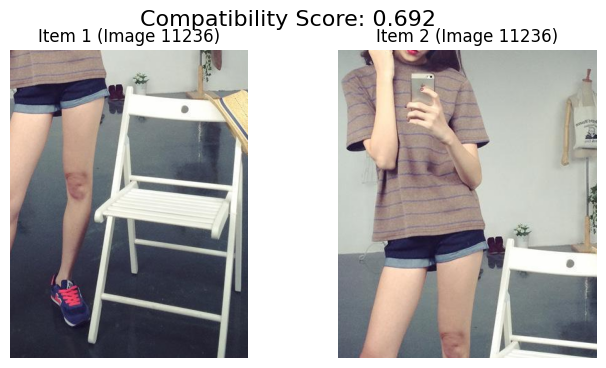


--- 부정 쌍 예시 (서로 다른 착장의 아이템들) ---


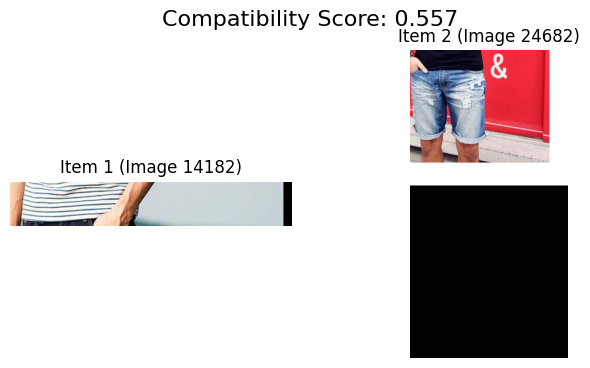

In [20]:
# H2 - C1. 추론 및 시각화
import matplotlib.pyplot as plt
import os
import json
import random

# --- 1. 검증용(validation) 데이터 어노테이션 파싱 ---
print("Parsing validation annotations from 'annos' directory...")
val_ann_dir = os.path.join(FINAL_DATA_DIR, 'validation', 'annos')
val_items_by_image = {}
for json_file in os.listdir(val_ann_dir):
    if not json_file.endswith('.json'): continue
    image_id = int(os.path.splitext(json_file)[0])
    try:
        with open(os.path.join(val_ann_dir, json_file), 'r') as f: ann = json.load(f)
        val_items_by_image[image_id] = [v for k, v in ann.items() if k.startswith('item')]
    except: continue
val_image_ids_with_pairs = [img_id for img_id, items in val_items_by_image.items() if len(items) >= 2]
val_image_dir = os.path.join(FINAL_DATA_DIR, 'validation', 'image')
print(f"Parsing complete. Found {len(val_image_ids_with_pairs)} validation images with 2+ items.")

# --- 2. H2 모델 로드 ---
print(f"\nLoading H2 model from: {H2_CHECKPOINT_PATH}")
# 모델 구조를 먼저 정의해야 로드할 수 있습니다.
h2_model_for_inference = SiameseModel() 
h2_model_for_inference.load_state_dict(torch.load(H2_CHECKPOINT_PATH, map_location=DEVICE))
h2_model_for_inference.eval() # 평가 모드로 설정
print("H2 model loaded successfully.")

# --- 3. 추론용 함수 정의 ---
def get_item_embedding(model, image_path, box):
    item_img = crop_item(image_path, box)
    item_tensor = preprocess(item_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        raw_embedding = model.encoder(item_tensor)
        final_embedding = model.projection_head(raw_embedding)
    return final_embedding

def visualize_compatibility(model, img_id1, item_info1, img_id2, item_info2):
    path1 = os.path.join(val_image_dir, f"{img_id1:06}.jpg")
    path2 = os.path.join(val_image_dir, f"{img_id2:06}.jpg")
    
    emb1 = get_item_embedding(model, path1, item_info1['bounding_box'])
    emb2 = get_item_embedding(model, path2, item_info2['bounding_box'])

    score = torch.nn.functional.cosine_similarity(emb1, emb2).item()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(crop_item(path1, item_info1['bounding_box']))
    axes[0].set_title(f"Item 1 (Image {img_id1})")
    axes[0].axis('off')
    
    axes[1].imshow(crop_item(path2, item_info2['bounding_box']))
    axes[1].set_title(f"Item 2 (Image {img_id2})")
    axes[1].axis('off')
    
    fig.suptitle(f"Compatibility Score: {score:.3f}", fontsize=16)
    plt.show()

# --- 4. 실행 예시 ---
print("\n--- 긍정 쌍 예시 (같은 착장의 아이템들) ---")
positive_img_id = random.choice(val_image_ids_with_pairs)
item1, item2 = random.sample(val_items_by_image[positive_img_id], 2)
visualize_compatibility(h2_model_for_inference, positive_img_id, item1, positive_img_id, item2)

print("\n--- 부정 쌍 예시 (서로 다른 착장의 아이템들) ---")
negative_img_id_1, negative_img_id_2 = random.sample(val_image_ids_with_pairs, 2)
item3 = random.choice(val_items_by_image[negative_img_id_1])
item4 = random.choice(val_items_by_image[negative_img_id_2])
visualize_compatibility(h2_model_for_inference, negative_img_id_1, item3, negative_img_id_2, item4)

Loading H1 and H2 models...
Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
All models loaded successfully.

--- Inferencing for Image ID: 16089 ---


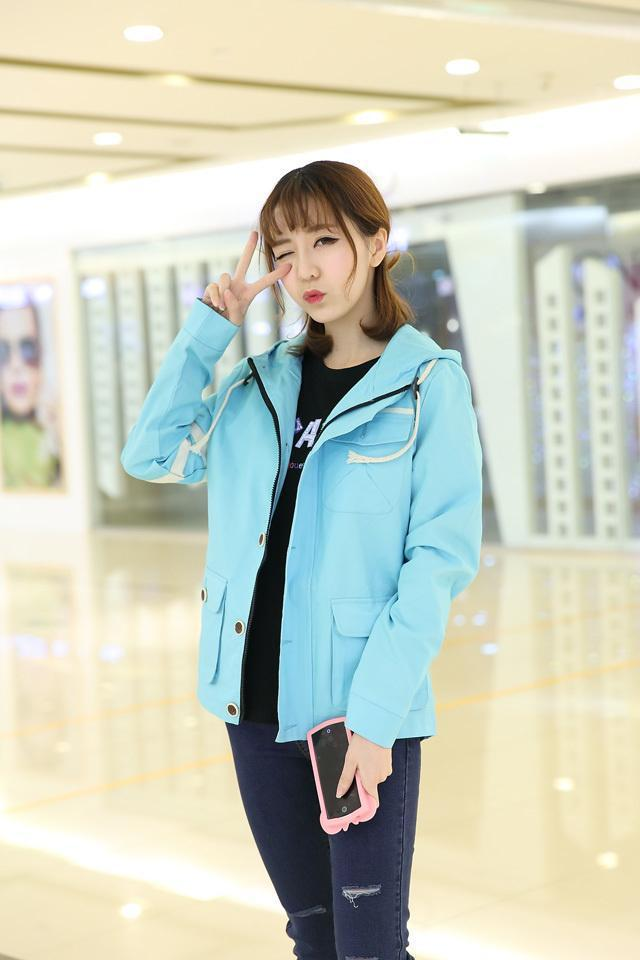


--- Comprehensive Score ---
{
  "final_score": 7.35,
  "details": {
    "aesthetics_score (H1)": 5.95,
    "compatibility_score (H2)": 9.44
  },
  "item_count": 2
}


In [22]:
# X1. (수정됨) 최종 통합 코드

# --- 1. 필요한 모델 로드 ---
print("Loading H1 and H2 models...")

# H1 모델 로드
h1_model = H1Regressor(clip_model)
h1_model.load_state_dict(torch.load(best_checkpoint_path, map_location=DEVICE))
h1_model.to(DEVICE)  # <-- 이 줄을 추가하여 모델 전체를 GPU로 보냅니다.
h1_model.eval()

# H2 모델 로드
h2_model = SiameseModel()
h2_model.load_state_dict(torch.load(H2_CHECKPOINT_PATH, map_location=DEVICE))
# h2_model은 이미 내부적으로 GPU로 이동되므로 추가 작업이 필요 없습니다.
h2_model.eval()
print("All models loaded successfully.")


# --- 2. 종합 점수 계산 함수 (이전과 동일) ---
def get_comprehensive_score(image_id, items_info):
    image_path = os.path.join(val_image_dir, f"{image_id:06}.jpg")
    
    # --- Score_A (심미성 점수) 계산 ---
    pil_image = Image.open(image_path).convert("RGB")
    clip_input = clip_preprocess(pil_image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score_a = h1_model(clip_input).item()

    # --- Score_C (궁합 점수) 계산 ---
    if len(items_info) < 2:
        score_c = 0.5 
    else:
        item_embeddings = []
        for item in items_info:
            emb = get_item_embedding(h2_model, image_path, item['bounding_box'])
            item_embeddings.append(emb)
        
        all_pair_scores = []
        for i in range(len(item_embeddings)):
            for j in range(i + 1, len(item_embeddings)):
                score = torch.nn.functional.cosine_similarity(item_embeddings[i], item_embeddings[j]).item()
                all_pair_scores.append(score)
        
        score_c = sum(all_pair_scores) / len(all_pair_scores) if all_pair_scores else 0.5

    # --- 최종 점수 합산 ---
    score_a_scaled = score_a 
    score_c_scaled = (score_c + 1) * 4.5 + 1
    
    final_score = (0.6 * score_a_scaled) + (0.4 * score_c_scaled)

    return {
        "final_score": round(final_score, 2),
        "details": {
            "aesthetics_score (H1)": round(score_a_scaled, 2),
            "compatibility_score (H2)": round(score_c_scaled, 2)
        },
        "item_count": len(items_info)
    }

# --- 3. 실행 예시 (이전과 동일) ---
sample_image_id = random.choice(val_image_ids_with_pairs)
items_in_sample = val_items_by_image[sample_image_id]

print(f"\n--- Inferencing for Image ID: {sample_image_id} ---")
display(Image.open(os.path.join(val_image_dir, f"{sample_image_id:06}.jpg")))

final_result = get_comprehensive_score(sample_image_id, items_in_sample)

import json
print("\n--- Comprehensive Score ---")
print(json.dumps(final_result, indent=2))

In [24]:
# X2. (All-in-One) 폴더 전체 이미지 점수화

# --- 1. 여기에 점수를 매길 '폴더' 경로를 입력하세요 ---
FOLDER_TO_SCORE = "/home/epistao/projects/fashion_ai/test_images/Fashion_mosaic/"


# --- 2. 기본 설정, 함수 및 클래스 정의 (수정할 필요 없음) ---
import os, json, random, math, cv2, torch, open_clip
import torch.nn as nn
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist
import torchvision.transforms as T
from IPython.display import display
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 20251009
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

HOME_DIR = os.path.expanduser("~")
PROJECT_DIR = os.path.join(HOME_DIR, "projects/fashion_ai")
# 체크포인트 경로 확인
H1_CHECKPOINT_PATH = [os.path.join(PROJECT_DIR, "checkpoints", f) for f in os.listdir(os.path.join(PROJECT_DIR, "checkpoints")) if f.startswith('h1_best_epoch')][0]
H2_CHECKPOINT_PATH = os.path.join(PROJECT_DIR, "checkpoints/h2_best_epoch1.pt")

# Helper Functions
def to_lab(np_img): return cv2.cvtColor(np_img.astype(np.uint8), cv2.COLOR_RGB2LAB)
def extract_palette_feats(np_img, K=5, sample=160*160):
    lab_img=to_lab(np_img); H,W,_=lab_img.shape; pixel_data=lab_img.reshape(-1,3)
    if H*W>sample: pixel_data=pixel_data[np.random.choice(H*W,sample,replace=False)]
    kmeans=KMeans(n_clusters=K,n_init='auto',random_state=SEED); kmeans.fit(pixel_data); centers=kmeans.cluster_centers_
    L=centers[:,0]/255.0; a=(centers[:,1]-128)/127.0; b=(centers[:,2]-128)/127.0; sat=np.sqrt(a**2+b**2)
    contrast_l=np.clip(np.std(L),0,0.5)/0.5; sat_balance=1.0-np.clip(np.std(sat)/0.4,0,1)
    harmony_dist=pdist(np.stack([a,b],axis=1))
    if len(harmony_dist)==0: harmony=0.5
    else: d_std=np.std(harmony_dist); harmony=np.exp(-((d_std-0.4)**2)/(2*0.12**2)); harmony=float(np.clip(harmony,0,1))
    return dict(contrast_l=float(contrast_l),sat_balance=float(sat_balance),harmony=float(harmony))
def thirds_score(H,W,cx=None,cy=None):
    if cx is None: cx=W/2
    if cy is None: cy=H/2
    pts=[(W/3,H/3),(2*W/3,H/3),(W/3,2*H/3),(2*W/3,2*H/3)]; d=min([math.hypot(cx-x,cy-y) for x,y in pts])
    norm_factor=math.hypot(W,H); score=1.0-np.clip(d/(norm_factor*0.3),0,1); return float(score)
def lr_balance(np_img):
    if len(np_img.shape)!=3 or np_img.shape[2]!=3: return 0.5
    gray=cv2.cvtColor(np_img,cv2.COLOR_RGB2GRAY); sobel_x=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3); sobel_y=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    energy=np.sqrt(sobel_x**2+sobel_y**2); mid=energy.shape[1]//2; L_energy=energy[:,:mid].sum(); R_energy=energy[:,mid:].sum()
    ratio=min(L_energy,R_energy)/(max(L_energy,R_energy)+1e-6); return float(ratio)
def bg_clutter(np_img):
    if len(np_img.shape)!=3 or np_img.shape[2]!=3: return 0.5
    gray=cv2.cvtColor(np_img,cv2.COLOR_RGB2GRAY); sobel_x=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3); sobel_y=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    energy=np.sqrt(sobel_x**2+sobel_y**2); clutter_val=np.mean(energy)/50.0; return float(np.clip(clutter_val,0,1))
def teacher_score(np_img):
    weights=dict(w_color=0.25,w_contrast=0.15,w_sat=0.10,w_thirds=0.20,w_balance=0.10,w_bg=-0.10,bias=0.30)
    H,W,_=np_img.shape; pal_feats=extract_palette_feats(np_img); thirds=thirds_score(H,W); balance=lr_balance(np_img); clutter=bg_clutter(np_img)
    raw_score=(weights['w_color']*pal_feats['harmony']+weights['w_contrast']*pal_feats['contrast_l']+weights['w_sat']*pal_feats['sat_balance']+weights['w_thirds']*thirds+weights['w_balance']*balance+weights['w_bg']*clutter+weights['bias'])
    raw_score=float(np.clip(raw_score,0,1)); final_score=1.0+9.0*raw_score; return float(final_score),{}
def load_image(path,target_size=336):
    img=Image.open(path).convert("RGB"); img=ImageOps.exif_transpose(img); img=ImageOps.contain(img,(target_size,target_size)); return img
def crop_item(image_path,box):
    full_image=Image.open(image_path).convert("RGB"); x,y,w,h=box; return full_image.crop((x,y,x+w,y+h))

# Model Classes
class H1Regressor(nn.Module):
    def __init__(self, clip_model):
        super().__init__(); self.clip=clip_model.visual
        for p in self.clip.parameters(): p.requires_grad=False
        D=self.clip.output_dim; self.head=nn.Sequential(nn.LayerNorm(D),nn.Linear(D,D//2),nn.GELU(),nn.Linear(D//2,1))
    def forward(self,x):
        with torch.no_grad(): embedding=self.clip(x)
        output=self.head(embedding).squeeze(1); return torch.sigmoid(output)*9.0+1.0
class SiameseModel(nn.Module):
    def __init__(self, clip_model):
        super(SiameseModel, self).__init__(); self.encoder = clip_model.visual
        for param in self.encoder.parameters(): param.requires_grad = False
        embedding_dim = self.encoder.output_dim; projection_dim = 128
        self.projection_head = nn.Sequential(nn.Linear(embedding_dim, embedding_dim), nn.ReLU(), nn.Linear(embedding_dim, projection_dim)).to(DEVICE)
    def forward(self, anchor, positive, negative):
        anchor_embedding = self.encoder(anchor); positive_embedding = self.encoder(positive); negative_embedding = self.encoder(negative)
        anchor_proj = self.projection_head(anchor_embedding); positive_proj = self.projection_head(positive_embedding); negative_proj = self.projection_head(negative_embedding)
        return anchor_proj, positive_proj, negative_proj

# --- 3. 모델 로드 ---
print("Loading models...")
clip_model,_,clip_preprocess=open_clip.create_model_and_transforms("ViT-B-32",pretrained="laion2b_s34b_b79k",device=DEVICE)
h1_model=H1Regressor(clip_model); h1_model.load_state_dict(torch.load(H1_CHECKPOINT_PATH,map_location=DEVICE)); h1_model.to(DEVICE); h1_model.eval()
h2_model=SiameseModel(clip_model); h2_model.load_state_dict(torch.load(H2_CHECKPOINT_PATH,map_location=DEVICE)); h2_model.eval()
print("Models loaded successfully.")

# --- 4. 객체 탐지 모델 (!!! 중요: 현재는 예시용 가짜 모델입니다 !!!) ---
def detect_objects(image_path):
    # 실제 모델이라면 이미지에서 아이템 bounding box를 찾아서 리턴해야 합니다.
    img = Image.open(image_path); w, h = img.size
    top = {'box': [w*0.2, h*0.1, w*0.6, h*0.6], 'label': 'top'}
    bottom = {'box': [w*0.25, h*0.5, w*0.5, h*0.45], 'label': 'bottom'}
    return [top, bottom]

# --- 5. 최종 점수 계산 함수 ---
@torch.no_grad()
def get_comprehensive_score(image_path):
    # Score_A (심미성)
    score_a = h1_model(clip_preprocess(load_image(image_path, 336)).unsqueeze(0).to(DEVICE)).item()
    
    # Score_C (궁합)
    detected_items = detect_objects(image_path)
    if len(detected_items) < 2:
        score_c = 0.5
    else:
        item_embeddings = []
        for item in detected_items:
            # H2 모델의 forward는 3개 입력을 받으므로, encoder와 head를 직접 사용
            item_img_cropped = crop_item(image_path, item['box'])
            item_tensor = clip_preprocess(item_img_cropped).unsqueeze(0).to(DEVICE)
            raw_emb = h2_model.encoder(item_tensor)
            final_emb = h2_model.projection_head(raw_emb)
            item_embeddings.append(final_emb)
            
        all_pair_scores = [torch.nn.functional.cosine_similarity(item_embeddings[i],item_embeddings[j]).item() for i in range(len(item_embeddings)) for j in range(i+1,len(item_embeddings))]
        score_c = sum(all_pair_scores)/len(all_pair_scores) if all_pair_scores else 0.5

    # 최종 점수 합산
    score_a_scaled=score_a; score_c_scaled=(score_c+1)*4.5+1
    final_score=(0.6*score_a_scaled)+(0.4*score_c_scaled)
    
    return {"final_score":round(final_score,2), "aesthetics_score(H1)":round(score_a_scaled,2), "compatibility_score(H2)":round(score_c_scaled,2)}

# --- 6. 최종 실행 (폴더 전체) ---
results_list = []
if os.path.isdir(FOLDER_TO_SCORE):
    image_files = [f for f in os.listdir(FOLDER_TO_SCORE) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"\nFound {len(image_files)} images. Starting scoring...")
    
    for filename in tqdm(image_files):
        image_path = os.path.join(FOLDER_TO_SCORE, filename)
        try:
            score_result = get_comprehensive_score(image_path)
            score_result['filename'] = filename
            results_list.append(score_result)
        except Exception as e:
            print(f"Could not score {filename}: {e}")

    if results_list:
        df_results = pd.DataFrame(results_list)
        df_results = df_results[['filename', 'final_score', 'aesthetics_score(H1)', 'compatibility_score(H2)']]
        print("\n--- 최종 점수 결과 ---")
        display(df_results)
    else:
        print("No results to display.")
else:
    print(f"\nError: Directory not found at '{FOLDER_TO_SCORE}'. Please check the path.")

Loading models...
Models loaded successfully.

Found 65 images. Starting scoring...


  0%|          | 0/65 [00:00<?, ?it/s]


--- 최종 점수 결과 ---


,filename,final_score,aesthetics_score(H1),compatibility_score(H2)
0,mosaic_524767516_18411317650106872_16176644009...,7.05,6.03,8.57
1,mosaic_475405249_18385110598106872_16194976354...,6.89,5.88,8.40
2,mosaic_528320195_18365977879150416_43793107911...,6.99,6.01,8.47
3,mosaic_514694359_18362101444150416_22196381387...,6.86,5.85,8.36
4,mosaic_476965529_18387111328106872_85792322713...,7.03,5.94,8.68
...,...,...,...,...
60,mosaic_525275168_18364830082150416_67325061668...,6.85,5.89,8.29
61,mosaic_455601932_1656337681854739_740901108722...,7.06,5.86,8.85
62,mosaic_515174729_18362101426150416_22672719929...,7.13,6.05,8.75
63,mosaic_479171830_18387229921106872_87434169120...,7.15,6.10,8.72
